# Volcano Eruptions

Which volcanoes have experienced the longest eruptions?

The dataset `volcanic-eruptions.csv` includes the start and end dates for all volcanic eruptions since 1800, along with each volcano's identification number. For eruptions that are still ongoing as of December 2024, the end date is recorded as December 2024.

This dataset excludes any eruptive pauses shorter than three months. If an eruption resumes after more than three months of inactivity, it is classified as a new eruption.

Note: Volcano Yasur in Vanuatu is not included in this list due to the absence of a clear start date.

In [1]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'volcanic-eruptions.csv' and 'volcano-list.csv'.

# from google.colab import files
# uploaded = files.upload()

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

eruptions = pd.read_csv('volcanic-eruptions.csv')
eruptions.head(3)

,volcano_id,start_date,end_date
0,211020,07-1913,04-1944
1,211020,02-1864,11-1868
2,211020,12-1854,05-1855


### Additional dataset

The dataset `volcano-list.csv` provides detailed information about each volcano, including its name, country, latitude, longitude, and type.

In [3]:
volcanoes = pd.read_csv('volcano-list.csv')
volcanoes.head(3)

,volcano_id,volcano_name,country,volcanic_region_group,volcanic_region,volcano_landform,primary_volcano_type,activity_evidence,last_known_eruption,latitude,longitude,elevation_m,tectonic_setting,dominant_rock_type
0,210010,West Eifel Volcanic Field,Germany,European Volcanic Regions,Central European Volcanic Province,Cluster,Volcanic field,Eruption Dated,8300 BCE,50.170,6.850,600,Rift zone / Continental crust (>25 km),Foidite
1,210020,Chaine des Puys,France,European Volcanic Regions,Western European Volcanic Province,Cluster,Lava dome(s),Eruption Dated,4040 BCE,45.786,2.981,1464,Rift zone / Continental crust (>25 km),Basalt / Picro-Basalt
2,210030,Olot Volcanic Field,Spain,European Volcanic Regions,Western European Volcanic Province,Cluster,Volcanic field,Evidence Credible,Unknown,42.170,2.530,893,Intraplate / Continental crust (>25 km),Trachybasalt / Tephrite Basanite


### Project Ideas:

- Find the volcanoes that were erupting as of Dec 2024.

- Find the volcanoes that have had the longest volcanic eruptions. 

Hints:
- Use `pd.to_datetime`.

- Merge the volcanoes dataframe into eruptions.

- Before the merge, reduce the dataframes to the columns of interest.

- Use `df.sort_values`.

In [4]:
# YOUR CODE HERE (add additional cells as needed)


In [5]:
print(eruptions.columns)

Index(['volcano_id', 'start_date', 'end_date'], dtype='str')


In [6]:
merged = pd.merge(
    eruptions,
    volcanoes,
    on="volcano_id"
)

In [7]:
modern = volcanoes[
    ~volcanoes[
        "last_known_eruption"
    ].str.contains("BCE", na=False)
]

In [8]:
modern["eruption_year"] = pd.to_numeric(
    modern["last_known_eruption"],
    errors="coerce"
)

In [9]:
recent = modern[
    modern["eruption_year"] >= 2000
]

In [10]:
print(
    recent[
        [
            "volcano_name",
            "country",
            "eruption_year"
        ]
    ]
)

Empty DataFrame
Columns: [volcano_name, country, eruption_year]
Index: []


In [11]:
volcanoes[
    "volcanic_region_group"
].value_counts()

volcanic_region_group
Northwest Pacific Volcanic Regions           212
South America Volcanic Regions               157
North America Volcanic Regions               149
Middle America-Caribbean Volcanic Regions    104
Eastern Africa Volcanic Regions               98
Sunda-Banda Volcanic Regions                  91
Western Pacific Volcanic Regions              88
Southwest Pacific Volcanic Regions            66
Atlantic Ocean Volcanic Regions               56
Tonga-Kermadec Volcanic Regions               45
Eastern Pacific Volcanic Regions              43
Antarctic-Scotia Volcanic Regions             28
Arabia-Central Asia Volcanic Regions          27
Northern Africa Volcanic Regions              27
European Volcanic Regions                     24
Eastern Asia Volcanic Regions                 24
Somalian-Antarctic Volcanic Regions           20
Southern Pacific Volcanic Regions             20
Eastern Australia Volcanic Regions             2
Name: count, dtype: int64

In [12]:
highest = volcanoes.sort_values(
    "elevation_m",
    ascending=False
)

print(
    highest[
        [
            "volcano_name",
            "country",
            "elevation_m"
        ]
    ].head(10)
)

                  volcano_name          country  elevation_m
1097  Ojos del Salado, Nevados  Chile-Argentina         6879
1089              Llullaillaco  Chile-Argentina         6739
1106                     Tipas        Argentina         6658
1096      Incahuasi, Nevado de  Chile-Argentina         6638
1052                  Coropuna             Peru         6377
1103                Condor, El        Argentina         6373
1066                Parinacota    Chile-Bolivia         6336
1032                Chimborazo          Ecuador         6261
1086                     Pular            Chile         6233
1098                  Solo, El  Chile-Argentina         6205


In [13]:
volcanoes[
    "primary_volcano_type"
].value_counts()

primary_volcano_type
Stratovolcano          583
Volcanic field         158
Stratovolcano(es)      112
Shield                 101
Caldera                 80
Complex                 55
Fissure vent(s)         34
Pyroclastic cone(s)     29
Lava dome(s)            25
Fissure vent            19
Compound                16
Shield(s)               13
Pyroclastic cone        10
Caldera(s)               7
Lava dome                7
Maar(s)                  5
Crater rows              5
Maar                     5
Tuff cone(s)             4
Shield(pyroclastic)      3
Lava cone                2
Stratovolcano?           2
Cone                     2
Explosion crater(s)      1
Tuff ring(s)             1
Tuff cone                1
Lava cone(es)            1
Name: count, dtype: int64

<Axes: ylabel='Frequency'>

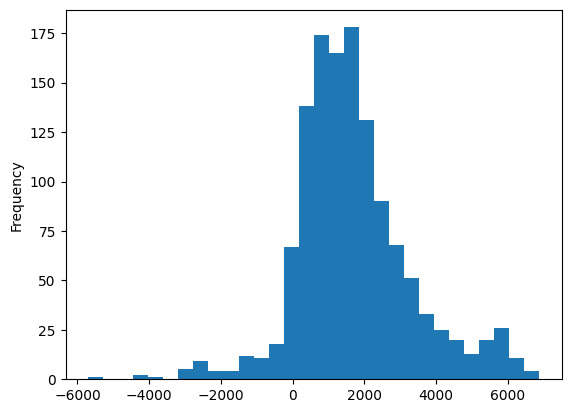

In [14]:
volcanoes["elevation_m"].plot.hist(
    bins=30
)

<Axes: xlabel='country'>

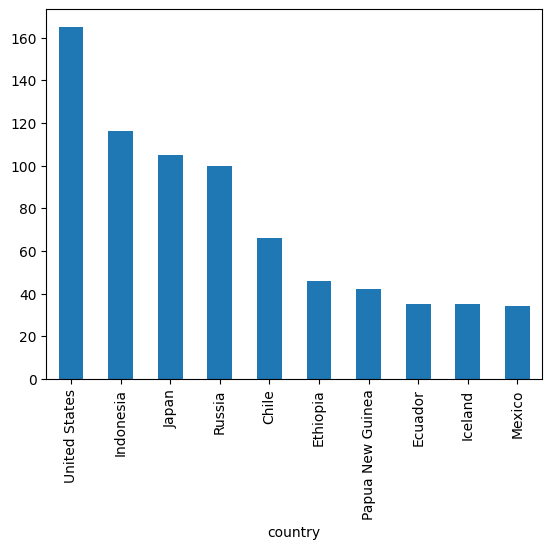

In [15]:
volcanoes["country"].value_counts().head(10).plot.bar()

<Axes: xlabel='primary_volcano_type'>

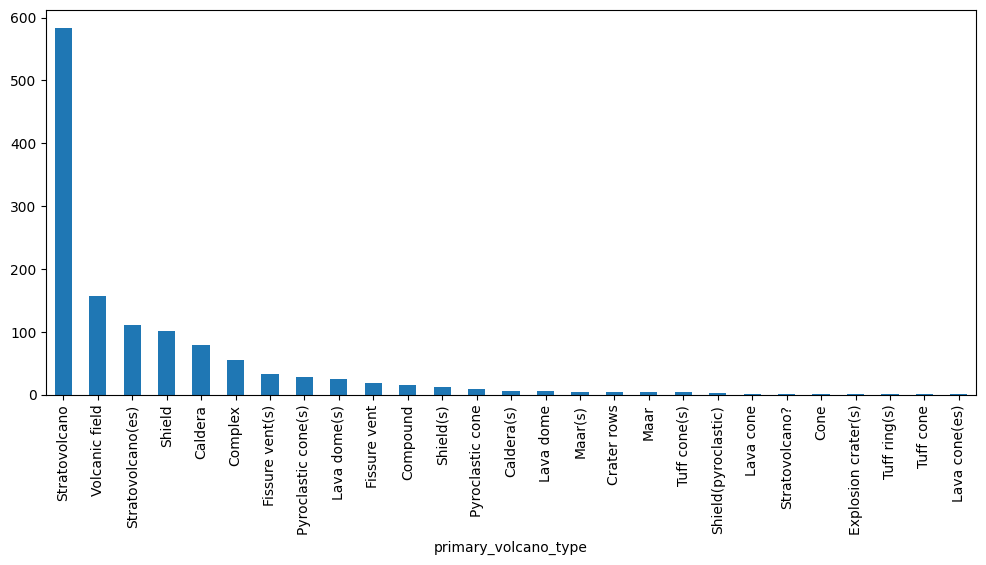

In [16]:
volcanoes[
    "primary_volcano_type"
].value_counts().plot.bar(
    figsize=(12,5)
)